## Data Ingestion & Initial Exploration
Below we load the dataset and view its basic structural attributes.

In [7]:
import pandas as pd
import numpy as np

# Load the dirty operational dataset
df = pd.read_csv('ops_sensor_log_dirty.csv')

# Output basic information and shape
print(f"Dataset Shape: {df.shape}")
print("\n--- DataFrame Information ---")
df.info()

Dataset Shape: (5015, 6)

--- DataFrame Information ---
<class 'pandas.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   str    
 1   Zone           4984 non-null   str    
 2   Shift          4962 non-null   str    
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), str(3)
memory usage: 235.2 KB


## Statistical Descriptive Profile
Generating summary statistics across numeric and categorical indicators to isolate anomalies.

In [8]:
# Descriptive summary for all columns
df.describe(include='all')

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,5015,4984,4962,4975.000000,4975.000000,4966.000000
unique,5000,15,3,NaN,NaN,NaN
top,2026-06-29 09:24:00,Zone_Central,Afternoon,NaN,NaN,NaN
freq,2,996,1715,NaN,NaN,NaN
mean,NaN,NaN,NaN,255.254281,68.982323,999.275681
std,NaN,NaN,NaN,845.810206,78.829078,231.769525
min,NaN,NaN,NaN,-50.000000,-273.150000,600.007437
25%,NaN,NaN,NaN,160.753008,55.023155,797.417014
50%,NaN,NaN,NaN,200.294439,64.808608,996.286415
75%,NaN,NaN,NaN,240.099173,74.527006,1201.361276


## Data Health Report

Based on the initial profiling metrics above, there are four critical data quality issues within the fictional processing plant dataset:

### Issue 1: Network Retry Duplication (Redundant Rows)
* **Symptom:** Running `df.duplicated().sum()` reveals exactly **15 row duplicates**, where entire sensor arrays and timestamps match identically.
* **Root Cause:** Network retry glitches. If a sensor node fails to receive a confirmation receipt from the local plant gateway, it re-transmits the exact packet.
* **Impact:** Distorts operational aggregations and artificially skews localized mean calculations.

### Issue 2: Extreme Sensor Calibration Failures & Hardware Error Spikes
* **Symptom:** 
  * `Pressure_PSI`: Displays an impossible maximum of **15,000.0 PSI** and an out-of-bounds minimum of **-50.0 PSI**.
  * `Temperature_C`: Displays an absolute zero error reading of **-273.15°C** and an impossible engine furnace spike of **1,500.0°C**.
* **Root Cause:** Hardcoded system error fallback triggers or hardware failure drift in the field diaphragms.
* **Impact:** Destroys engineering rolling trends and triggers false alarms on downstream dashboards.

### Issue 3: Inconsistent Categorical Labeling (String Pollution)
* **Symptom:** The `Zone` column lists **15 unique labels** instead of the distinct 5 operational zones. Values are polluted with case discrepancies (e.g., `Zone_South`, `ZONE_SOUTH`, `zone south`) and trailing/leading spaces (e.g., `'Zone_South '`, `' South Zone'`).
* **Root Cause:** Lack of string validation at data collection points or manually overridden text logs.
* **Impact:** Segmented pivot tables and group-by lookups fail to combine metrics from the same plant quadrant.

### Issue 4: Missing Telemetry Streams
* **Symptom:** Non-null columns show a systematic drop in packets across variables: `Zone` (31 missing), `Shift` (53 missing), `Pressure_PSI` (40 missing), `Temperature_C` (40 missing), and `Flow_Rate_LPM` (49 missing).
* **Root Cause:** Sensor drops, wireless interference, or structural machinery disconnects.
* **Impact:** Machine learning or diagnostic frameworks encounter runtime execution faults when encountering missing array slices.

## Reusable Function

`clean_ops_data(df)` that:
- Converts timestamps to datetime objects.
- Handles missing values (justify your choice: drop, fill, or interpolate).
- Removes duplicates.
- Standardizes categorical columns (e.g., location names).
- Filters out physically impossible sensor readings (outliers).

In [9]:
import pandas as pd
import numpy as np

def clean_ops_data(df):
    """Cleans and standardizes the plant operational dataset.
    
    Args:
    df (pd.DataFrame): Raw ingested sensor log DataFrame.
        
    Returns:
    pd.DataFrame: A fully structured, cleaned operational DataFrame.
    """
    # Create an explicit deep copy to avoid SettingWithCopyWarnings
    cleaned_df = df.copy()
    
    # Drop redundant rows created by network retry attempts
    cleaned_df = cleaned_df.drop_duplicates()
    
    # Convert timestamps to explicit datetime objects for continuous time-series analytics
    cleaned_df['timestamp'] = pd.to_datetime(cleaned_df['timestamp'])
    
    # String Cleaning
    if 'Zone' in cleaned_df.columns:
        # Step A: Strip out leading/trailing spaces and make uppercase for standard comparison
        cleaned_df['Zone'] = cleaned_df['Zone'].astype(str).str.strip().str.upper()
        
        # Step B: Map messy variations directly to the five official standardized plant segments
        zone_mapping = {
            'ZONE_CENTRAL': 'Zone_Central', 'CENTRAL ZONE': 'Zone_Central',
            'ZONE_NORTH': 'Zone_North', 'ZONE-NORTH': 'Zone_North', 'Z_NORTH': 'Zone_North', 'NORTH ZONE': 'Zone_North',
            'ZONE_WEST': 'Zone_West', 'WEST ZONE': 'Zone_West', 'Z_WEST': 'Zone_West',
            'ZONE_EAST': 'Zone_East', 'EAST ZONE': 'Zone_East', 'Z_EAST': 'Zone_East',
            'ZONE_SOUTH': 'Zone_South', 'Z_SOUTH': 'Zone_South', 'SOUTH ZONE': 'Zone_South',
            'NAN': np.nan  # Preserves missing statuses temporarily for imputation
        }
        cleaned_df['Zone'] = cleaned_df['Zone'].map(zone_mapping)
        
    if 'Shift' in cleaned_df.columns:
        cleaned_df['Shift'] = cleaned_df['Shift'].astype(str).str.strip().str.capitalize()
        cleaned_df['Shift'] = cleaned_df['Shift'].replace('Nan', np.nan)

    # Replacing impossible sensor indicators with NaN values so they don't corrupt rolling means
    
    # Pressure: Cannot drop below 0 PSI under normal flow; 15,000 PSI is an explicit sensor blowout error
    if 'Pressure_PSI' in cleaned_df.columns:
        invalid_pressure = (cleaned_df['Pressure_PSI'] < 0) | (cleaned_df['Pressure_PSI'] > 3000)
        cleaned_df.loc[invalid_pressure, 'Pressure_PSI'] = np.nan
        
    # Temperature: -273.15°C (Absolute Zero) and 1,500°C are clear sensor hardware faults
    if 'Temperature_C' in cleaned_df.columns:
        invalid_temp = (cleaned_df['Temperature_C'] <= -50) | (cleaned_df['Temperature_C'] > 200)
        cleaned_df.loc[invalid_temp, 'Temperature_C'] = np.nan
    
    # Filling numeric telemetry signals using forward-fill
    numeric_cols = ['Pressure_PSI', 'Temperature_C', 'Flow_Rate_LPM']
    for col in numeric_cols:
        if col in cleaned_df.columns:
            cleaned_df[col] = cleaned_df[col].ffill().bfill() # bfill handles a missing start row if present
            
    # Fill categorical slots using structural modes
    for col in ['Zone', 'Shift']:
        if col in cleaned_df.columns:
            plant_mode = cleaned_df[col].mode()[0]
            cleaned_df[col] = cleaned_df[col].fillna(plant_mode)
            
    return cleaned_df

In [10]:
# Pass the raw, dirty dataframe through our custom function
print(f"Raw data shape before pipeline: {df.shape}")

cleaned_df = clean_ops_data(df)

print(f"Cleaned data shape after pipeline: {cleaned_df.shape}")

Raw data shape before pipeline: (5015, 6)
Cleaned data shape after pipeline: (5000, 6)


In [11]:
# TIME-SERIES SET-UP: INDEXING & SORTING

# Setting the parsed timestamp column as the explicit DataFrame Index
df_time = cleaned_df.set_index('timestamp')

# Enforcing strict chronological order to guarantee linear rolling windows
df_time = df_time.sort_index()

# Filtering out the rogue January telemetry packet to focus on the main window
# (Initial profiling revealed a lone outlier record from 2026-01-07)
main_window_df = df_time[df_time.index >= '2026-06-01']

In [13]:
# HOURLY RESAMPLING & 24-HOUR ROLLING AVERAGE

# Resampling the 1-minute streams into 1-Hour averages using the mean
hourly_df = main_window_df[['Pressure_PSI']].resample('1h').mean()

# Calculating the 24-Hour Rolling Average
# min_periods=1 ensures data populates immediately instead of waiting 24 hours
hourly_df['Pressure_24h_Rolling_Avg'] = (
    hourly_df['Pressure_PSI']
    .rolling(window=24, min_periods=1)
    .mean()
)

# Displaying a snapshot of the processed operational data
print("\n--- Processed Hourly & Rolling Telemetry (Head) ---")
print(hourly_df.head())


--- Processed Hourly & Rolling Telemetry (Head) ---
                     Pressure_PSI  Pressure_24h_Rolling_Avg
timestamp                                                  
2026-06-25 00:00:00    201.380407                201.380407
2026-06-25 01:00:00    196.280484                198.830446
2026-06-25 02:00:00    188.648468                195.436453
2026-06-25 03:00:00    198.603934                196.228323
2026-06-25 04:00:00    191.045077                195.191674


In [14]:
# Generating the multi-aggregation pivot table
summary_table = cleaned_df.groupby(['Zone', 'Shift'])['Pressure_PSI'].agg(['mean', 'max', 'min'])

print("=== Operational Metrics Summary Table ===")
display(summary_table)

=== Operational Metrics Summary Table ===


mean         max         min
Zone         Shift                                        
Zone_Central Afternoon  199.675786  279.941700    0.000000
             Morning    198.088703  279.892787    0.000000
             Night      198.781148  279.919416  120.181036
Zone_East    Afternoon  203.943976  278.852932  120.863767
             Morning    197.622293  279.953222    0.000000
             Night      201.273258  279.890603  120.454745
Zone_North   Afternoon  202.393304  279.854523    0.000000
             Morning    202.715231  279.523489    0.000000
             Night      199.642171  279.958604    0.000000
Zone_South   Afternoon  203.147796  279.724389    0.000000
             Morning    195.442015  279.108960  121.281303
             Night      198.285852  278.702857    0.000000
Zone_West    Afternoon  197.097387  279.607715    0.000000
             Morning    194.994779  279.898389  120.572407
             Night      199.092510  279.613215    0.000000

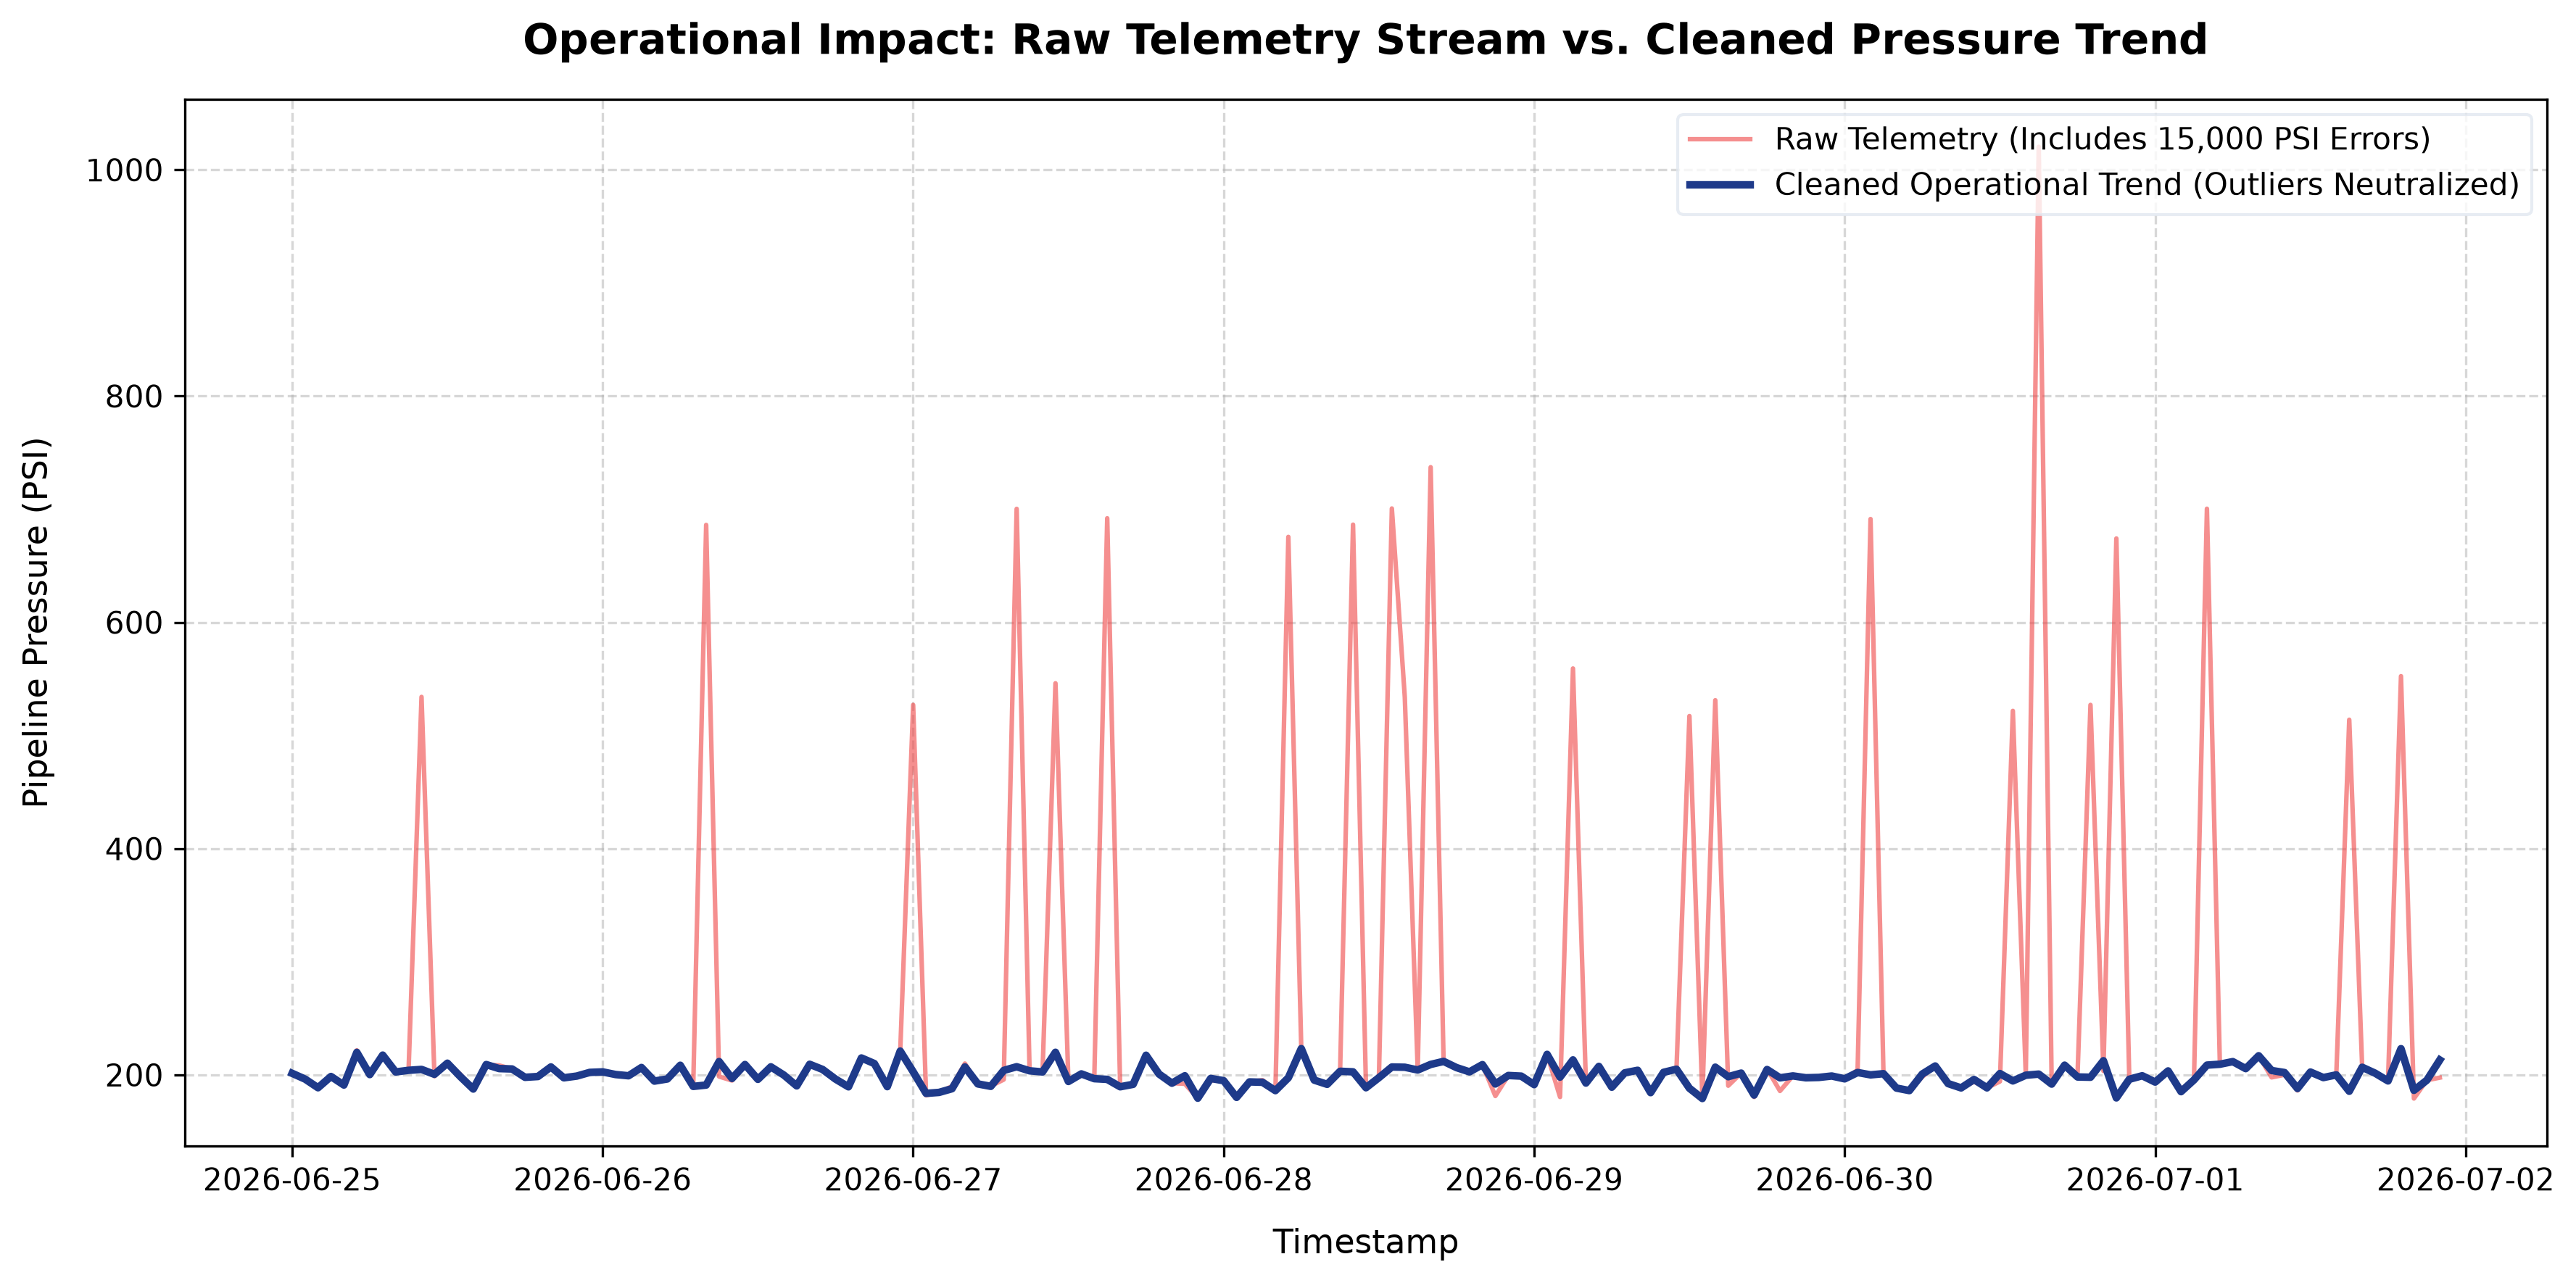

In [15]:
import matplotlib.pyplot as plt

# Aligning datasets chronologically for index comparison (ignoring the rogue Jan entry)
df_raw_plot = df.copy()
df_raw_plot['timestamp'] = pd.to_datetime(df_raw_plot['timestamp'])
df_raw_plot = df_raw_plot.set_index('timestamp').sort_index()
df_raw_plot = df_raw_plot[df_raw_plot.index >= '2026-06-01']

df_clean_plot = cleaned_df.set_index('timestamp').sort_index()
df_clean_plot = df_clean_plot[df_clean_plot.index >= '2026-06-01']

# Resampling to an hourly frequency ('1h') for visual clarity
raw_hourly = df_raw_plot['Pressure_PSI'].resample('1h').mean()
clean_hourly = df_clean_plot['Pressure_PSI'].resample('1h').mean()

# Constructing the polished visualization
plt.figure(figsize=(12, 6), dpi=300)
plt.plot(raw_hourly.index, raw_hourly.values, color='#ef4444', alpha=0.6, label='Raw Telemetry (Includes 15,000 PSI Errors)', linewidth=1.5)
plt.plot(clean_hourly.index, clean_hourly.values, color='#1e3a8a', label='Cleaned Operational Trend (Outliers Neutralized)', linewidth=2.5)

# Charting Polishing & Styling
plt.title('Operational Impact: Raw Telemetry Stream vs. Cleaned Pressure Trend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timestamp', fontsize=11, labelpad=10)
plt.ylabel('Pipeline Pressure (PSI)', fontsize=11, labelpad=10)
plt.legend(loc='upper right', frameon=True, facecolor='#ffffff', edgecolor='#e2e8f0')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Rendering inline
plt.show()